<a href="https://colab.research.google.com/github/ValeriaZav26/CelebA-Face-Attributes-Multi-task-Gender-Young-Classification/blob/main/Gender_Young_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Stage 0. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             ConfusionMatrixDisplay, RocCurveDisplay)

SEED = 42
tf.keras.utils.set_random_seed(SEED)

In [ ]:
DRIVE   = "/content/drive/MyDrive/DS"
IMG_SRC = f"{DRIVE}/img_align_celeba"
ATTR    = f"{DRIVE}/list_attr_celeba.txt"
LOCAL   = "/content/data"
OUT     = "/content/outputs"
BACKUP  = f"{DRIVE}/outputs"

for p in (LOCAL, OUT, BACKUP):
    os.makedirs(p, exist_ok=True)

# Find all .jpg files (at any folder depth): {"000001.jpg": "/full/path/000001.jpg"}
SRC_FILES = {}
for root, _, files in os.walk(IMG_SRC):
    for f in files:
        if f.lower().endswith(".jpg"):
            SRC_FILES[f] = os.path.join(root, f)

print("Found .jpg:", len(SRC_FILES))
assert len(SRC_FILES) > 0, "Photos not found — check IMG_SRC"
assert os.path.exists(ATTR), "Annotation file not found — check ATTR"

Found .jpg: 10839


## Stage 1. Labels, split and photo copy

We read list_attr_celeba.txt and take the columns we need (gender, young).
Important: the file name is taken from the file column, otherwise labels and photos get mixed up without any error.
The official CelebA split is based on indices (train <= 162770), but since we use a subsample, we split the data ourselves.

In [ ]:
# sep=r"\s+" — separator "any number of spaces"; skiprows=1 — skip the first line (the number 202599).
attr = pd.read_csv(ATTR, sep=r"\s+", skiprows=1)
attr.index.name = "file"
attr = (attr == 1).astype(int)              # -1/1  ->  0/1

# 2 target attributes + 3 auxiliary ones (for error analysis in stage 8).
df = attr[["Male", "Young", "Eyeglasses", "Wearing_Hat", "Smiling"]]
df = df.rename(columns={"Male": "gender", "Young": "young"})   # gender: 1 = MALE
df = df.reset_index()                       # file name from the index -> "file" column

# Keep only the rows whose photo actually exists on the Drive.
df["src"] = df["file"].map(SRC_FILES)
print("Rows in annotation:", len(df), "| photo available for:", df["src"].notna().sum())
df = df.dropna(subset=["src"]).reset_index(drop=True)

# Cap on the sample size to fit the time budget (None = take everything found).
MAX_IMAGES = 40000
if MAX_IMAGES and len(df) > MAX_IMAGES:
    df = df.sample(MAX_IMAGES, random_state=SEED).reset_index(drop=True)
print("Using photos:", len(df))

Rows in annotation: 202599 | photo available for: 10839
Using photos: 10839


In [ ]:
# Initial data analysis.
print("Share of men:", df.gender.mean().round(3), "(expected ~0.42)")
print("Share of young:", df.young.mean().round(3),  "(expected ~0.77)")
print("\nShare of young within each gender:")
print(pd.crosstab(df.gender, df.young, normalize="index").round(3))

maj_gender = max(df.gender.mean(), 1 - df.gender.mean())
maj_young  = max(df.young.mean(),  1 - df.young.mean())
print(f"\nBaseline accuracy: gender={maj_gender:.3f}, young={maj_young:.3f}")

Share of men: 0.421 (expected ~0.42)
Share of young: 0.778 (expected ~0.77)

Share of young within each gender:
young       0      1
gender              
0       0.118  0.882
1       0.364  0.636

Baseline accuracy: gender=0.579, young=0.778


In [ ]:
# 80% / 10% / 10% split with STRATIFICATION: all parts have the same share
# of combinations (gender x young), so the test set will have no random skew.
df["strat"] = df["gender"] * 2 + df["young"]

train_val, test_df = train_test_split(df, test_size=0.10, random_state=SEED,
                                      stratify=df["strat"])
train_df, val_df = train_test_split(train_val, test_size=1/9, random_state=SEED,
                                    stratify=train_val["strat"])

train_df, val_df, test_df = [d.reset_index(drop=True) for d in (train_df, val_df, test_df)]

# Leakage check: one photo must not end up in two subsets.
tr, va, te = set(train_df.file), set(val_df.file), set(test_df.file)
assert not (tr & va) and not (tr & te) and not (va & te), "Data leakage!"

for name, d in (("train", train_df), ("val", val_df), ("test", test_df)):
    print(f"{name:5s} n={len(d):6d}  men={d.gender.mean():.3f}  young={d.young.mean():.3f}")

train n=  8671  men=0.420  young=0.778
val   n=  1084  men=0.421  young=0.779
test  n=  1084  men=0.421  young=0.779


In [ ]:
# Copy the needed photos from Drive to the local Colab disk (training is faster from the local disk).
def copy_one(src):
    dst = os.path.join(LOCAL, os.path.basename(src))
    if not os.path.exists(dst):
        shutil.copy(src, dst)

all_src = pd.concat([train_df, val_df, test_df])["src"]
with ThreadPoolExecutor(max_workers=16) as ex:          # 16 threads copy in parallel
    list(tqdm(ex.map(copy_one, all_src), total=len(all_src)))

# The "path" column = path to the local copy. Built from the file name, NOT from the index.
for d in (train_df, val_df, test_df):
    d["path"] = LOCAL + "/" + d["file"]
    assert all(os.path.exists(p) for p in d["path"]), "Not all photos were copied"
print("Done. Example path:", train_df.path[0])

100%|██████████| 10839/10839 [04:28<00:00, 40.34it/s] 


Done. Example path: /content/data/000251.jpg


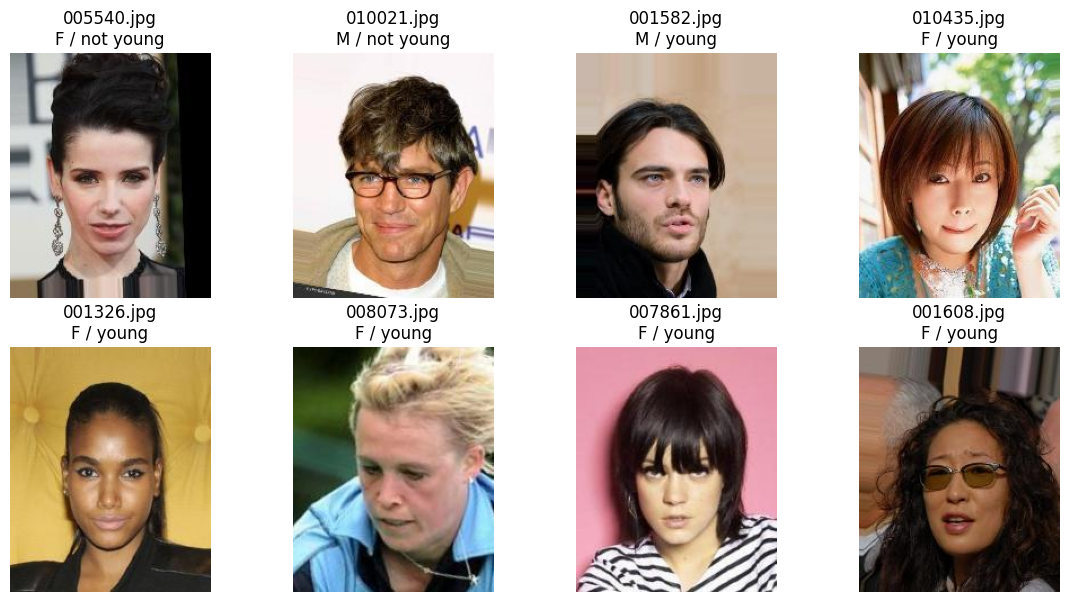

In [ ]:
# do the labels match the images?
sample = train_df.sample(8)
plt.figure(figsize=(14, 7))
for i, (_, row) in enumerate(sample.iterrows()):
    plt.subplot(2, 4, i + 1)
    plt.imshow(plt.imread(row["path"])); plt.axis("off")
    sex = "M" if row["gender"] == 1 else "F"
    age = "young" if row["young"] == 1 else "not young"
    plt.title(f"{row['file']}\n{sex} / {age}")
plt.show()

# Yes, the labels match the images


## Stage 2. Data pipeline (`tf.data`)

All the photos won't fit in memory, so `tf.data.Dataset` reads them in portions (batches): while the GPU processes one batch, the CPU prepares the next one.

The original CelebA images are 178×218. A plain `resize` to 128×128 would squash the face, so we first cut out a 178×178 square and then downscale it. Pixels stay in the 0..255 range, and the normalization (to −1..1) is done by the model itself.

In [21]:
IMG = 128
BATCH = 64
AUTOTUNE = tf.data.AUTOTUNE

def load_img(path):
    img = tf.io.decode_jpeg(tf.io.read_file(path), channels=3)
    img = tf.image.crop_to_bounding_box(img, 20, 0, 178, 178)
    return tf.image.resize(img, (IMG, IMG))

augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

def make_ds(d, train, batch=BATCH, w_young=None):
    ds = tf.data.Dataset.from_tensor_slices((
        d["path"].values.astype(str),
        d[["gender"]].values.astype("float32"),
        d[["young"]].values.astype("float32"),
    ))
    if train:
        ds = ds.shuffle(len(d), seed=SEED)

    if w_young is not None:
        w0, w1 = w_young


        def to_weighted(p, g, y):
            labels  = {"gender": g, "young": y}
            weights = {
                "gender": tf.ones_like(g),
                "young":  tf.where(y > 0.5, tf.cast(w1, tf.float32),
                                            tf.cast(w0, tf.float32)),
            }
            return load_img(p), labels, weights

        ds = ds.map(to_weighted, num_parallel_calls=AUTOTUNE)

        if train:
            ds = ds.map(lambda x, y, w: (augment(x, training=True), y, w),
                        num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.map(lambda p, g, y: (load_img(p), {"gender": g, "young": y}),
                    num_parallel_calls=AUTOTUNE)
        if train:
            ds = ds.map(lambda x, y: (augment(x, training=True), y),
                        num_parallel_calls=AUTOTUNE)
        else:
            ds = ds.cache()

    return ds.batch(batch).prefetch(AUTOTUNE)

train_ds = make_ds(train_df, True)
val_ds   = make_ds(val_df, False)
test_ds  = make_ds(test_df, False)

(64, 128, 128, 3) min/max: 0.0 255.0


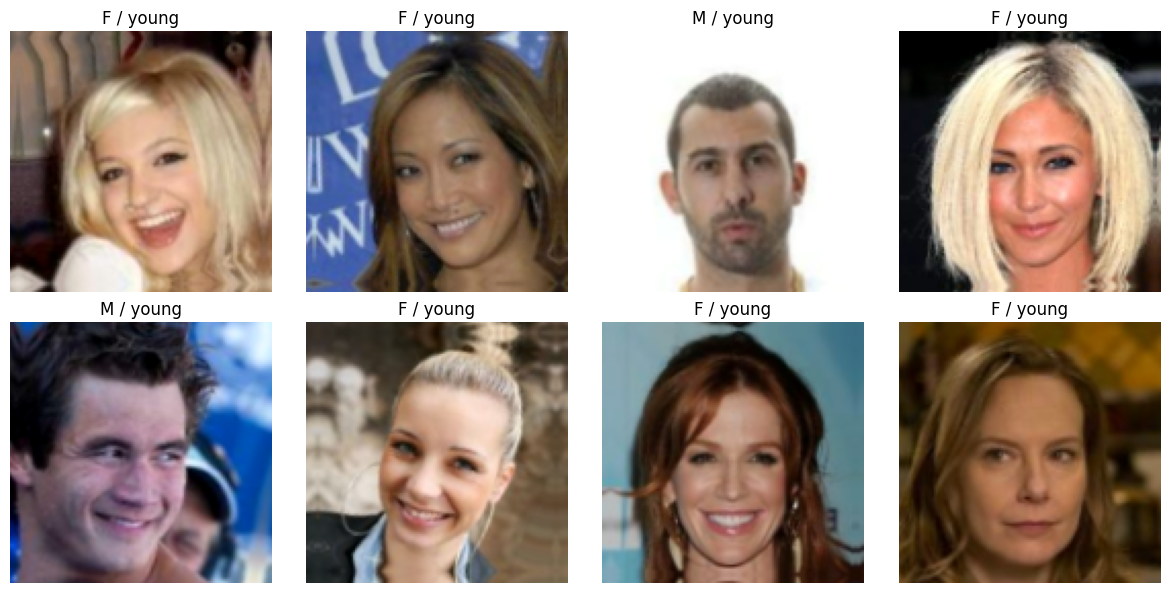

In [ ]:
#  batch and data check
x, y = next(iter(train_ds))
print(x.shape, "min/max:", x.numpy().min(), x.numpy().max())

# --- Grid of 8 different photos from the batch with captions ---
plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(x[i].numpy().astype("uint8")); plt.axis("off")
    plt.title(f"{'M' if y['gender'][i, 0] == 1 else 'F'} / "
              f"{'young' if y['young'][i, 0] == 1 else 'not young'}")
plt.tight_layout()
plt.show()

## Stage 3. Model

**Transfer learning:** MobileNetV2 has already been trained on ImageNet and can detect edges, textures and facial parts. We **freeze** its weights and train only two small "heads":

```
photo 128x128x3 (0..255) -> Rescaling (-1..1) -> MobileNetV2 (frozen)
   -> GlobalAveragePooling2D -> Dropout
        /                         \
  "gender" head              "young" head
  Dense(128) -> Dropout      Dense(128) -> Dropout
  Dense(1, sigmoid)          Dense(1, sigmoid)
```
Each head outputs a probability from 0 to 1. The loss is `binary_crossentropy`, the metric is `acc` (accuracy).

In [ ]:
from tensorflow.keras import layers

def make_head(x, name, dropout):
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    return layers.Dense(1, activation="sigmoid", name=name)(x)

def build_model(dropout=0.3):
    inputs = layers.Input(shape=(IMG, IMG, 3))
    x = layers.Rescaling(1 / 127.5, offset=-1.0)(inputs)
    backbone = tf.keras.applications.MobileNetV2(
        input_shape=(IMG, IMG, 3), include_top=False, weights="imagenet")
    backbone.trainable = False
    x = backbone(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    return tf.keras.Model(inputs, [make_head(x, "gender", dropout),
                                   make_head(x, "young", dropout)])

def compile_model(model, lr=1e-3):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss={"gender": "binary_crossentropy", "young": "binary_crossentropy"},
        metrics={"gender": [tf.keras.metrics.BinaryAccuracy(name="acc")],
                 "young":  [tf.keras.metrics.BinaryAccuracy(name="acc")]},
    )
    return model

model = compile_model(build_model())
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 128, 128,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_1… │ (None, 4, 4,      │  2,257,984 │ rescaling[0][0]   │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1280)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    163,968 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │    163,968 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender (Dense)      │ (None, 1)         │        129 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ young (Dense)       │ (None, 1)         │        129 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,586,178 (9.87 MB)

 Trainable params: 328,194 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Stage 4. The "overfit on 64 photos" test

We take 64 photos and train on those same photos, **without augmentations or dropout**. A healthy model must learn them almost perfectly (accuracy > 0.9). If it doesn't, there is a bug in the data, labels or paths, and training on the whole dataset makes no sense.

In [ ]:
small_df = train_df.sample(64, random_state=SEED)
small_ds = make_ds(small_df, train=False, batch=16)        # no augmentations

m_small = compile_model(build_model(dropout=0.0))           # no dropout
h_small = m_small.fit(small_ds, epochs=30, verbose=0)

acc_g = h_small.history["gender_acc"][-1]
acc_y = h_small.history["young_acc"][-1]
print(f"accuracy on 64 photos: gender={acc_g:.3f}  young={acc_y:.3f}")
print(acc_g, acc_y)
del m_small

accuracy on 64 photos: gender=1.000  young=1.000
1.0 1.0


## Stage 5. Training the heads (backbone frozen)

Reference values: gender accuracy ~92–96%, `young` accuracy ~78–83%. The baseline for `young` is already ≈ 0.77, so also look at F1 and ROC-AUC (stage 7).

In [ ]:
tf.keras.utils.set_random_seed(SEED)
model = compile_model(build_model(dropout=0.3), lr=1e-3)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(f"{BACKUP}/best.keras", monitor="val_loss",
                                       save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                     restore_best_weights=True),
]
history = model.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=callbacks)

Epoch 1/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - gender_acc: 0.8342 - gender_loss: 0.3733 - loss: 0.9064 - young_acc: 0.7709 - young_loss: 0.5331
Epoch 1: val_loss improved from None to 0.61766, saving model to /content/drive/MyDrive/DS/outputs/best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DS/outputs/best.keras
136/136 ━━━━━━━━━━━━━━━━━━━━ 186s 1s/step - gender_acc: 0.8692 - gender_loss: 0.3134 - loss: 0.7733 - young_acc: 0.7940 - young_loss: 0.4610 - val_gender_acc: 0.8994 - val_gender_loss: 0.2398 - val_loss: 0.6177 - val_young_acc: 0.8423 - val_young_loss: 0.3779
Epoch 2/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - gender_acc: 0.8907 - gender_loss: 0.2657 - loss: 0.6703 - young_acc: 0.8216 - young_loss: 0.4046
Epoch 2: val_loss improved from 0.61766 to 0.59526, saving model to /content/drive/MyDrive/DS/outputs/best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DS/outputs/best.keras
136/136 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - gender_acc: 0

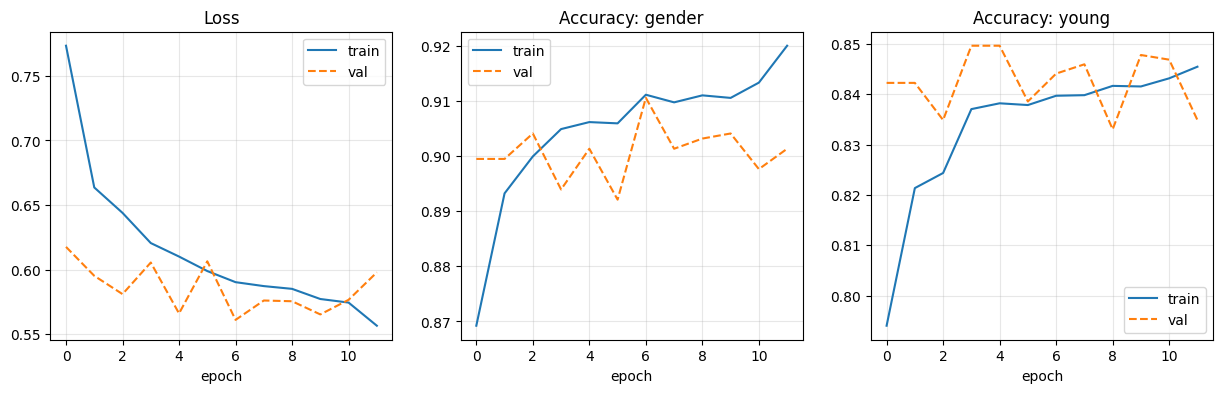

In [ ]:
def plot_history(history, title=""):
    # Learning curves: train (solid) and val (dashed).
    h = history.history
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    ax[0].plot(h["loss"], label="train")
    ax[0].plot(h["val_loss"], "--", label="val")
    ax[0].set_title("Loss")
    for a, task in zip(ax[1:], ("gender", "young")):
        a.plot(h[f"{task}_acc"], label="train")
        a.plot(h[f"val_{task}_acc"], "--", label="val")
        a.set_title(f"Accuracy: {task}")
    for a in ax:
        a.set_xlabel("epoch"); a.legend(); a.grid(alpha=0.3)
    fig.suptitle(title); plt.show()

plot_history(history)


#  * val_loss falls, val_acc grows    -> good;
#  * train much better than val       -> overfitting (increase dropout/augmentations);
#  * everything stays flat            -> underfitting (more epochs / check lr).

## Stage 6. Fine-tuning

We slightly adapt MobileNetV2 itself to faces. Rules for safe fine-tuning:
1. **a very small lr (1e-5)**, otherwise we will break the pretrained features;
2. unfreeze **not everything**, only the last N layers;
3. **keep the BatchNorm layers frozen**;
4. after changing `trainable`, **you must recompile**.

Epoch 1/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - gender_acc: 0.9129 - gender_loss: 0.2079 - loss: 0.5726 - young_acc: 0.8425 - young_loss: 0.3647
Epoch 1: val_loss improved from None to 0.54479, saving model to /content/drive/MyDrive/DS/outputs/best_ft.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DS/outputs/best_ft.keras
136/136 ━━━━━━━━━━━━━━━━━━━━ 246s 2s/step - gender_acc: 0.9126 - gender_loss: 0.2114 - loss: 0.5696 - young_acc: 0.8456 - young_loss: 0.3577 - val_gender_acc: 0.9170 - val_gender_loss: 0.2004 - val_loss: 0.5448 - val_young_acc: 0.8515 - val_young_loss: 0.3447
Epoch 2/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - gender_acc: 0.9215 - gender_loss: 0.1904 - loss: 0.5319 - young_acc: 0.8563 - young_loss: 0.3415
Epoch 2: val_loss improved from 0.54479 to 0.53576, saving model to /content/drive/MyDrive/DS/outputs/best_ft.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DS/outputs/best_ft.keras
136/136 ━━━━━━━━━━━━━━━━━━━━ 236s 2s/step - g

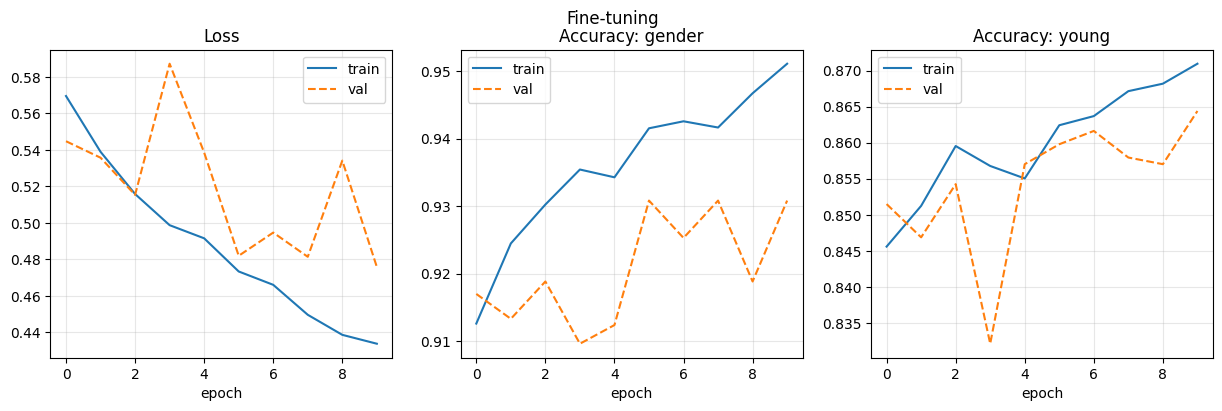

In [ ]:
tf.keras.utils.set_random_seed(SEED)
UNFREEZE_LAST = 40
ft_model = tf.keras.models.load_model(f"{BACKUP}/best.keras")
backbone = next(l for l in ft_model.layers if isinstance(l, tf.keras.Model))

backbone.trainable = True
for l in backbone.layers[:-UNFREEZE_LAST]:
    l.trainable = False
for l in backbone.layers:
    if isinstance(l, tf.keras.layers.BatchNormalization):
        l.trainable = False

ft_model = compile_model(ft_model, lr=1e-5)

ft_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(f"{BACKUP}/best_ft.keras", monitor="val_loss",
                                       save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3,
                                     restore_best_weights=True),
]
history_ft = ft_model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=ft_callbacks)
plot_history(history_ft, "Fine-tuning")

## Stage 7. Honest evaluation on the test set

In [ ]:
def get_probs(model, data):
    # Returns probabilities (P(male), P(young)) in the order of the data rows.
    p = model.predict(data, verbose=0)
    if isinstance(p, dict):
        p = [p["gender"], p["young"]]
    return p[0].ravel(), p[1].ravel()

results = []

def evaluate_model(model, name):
    probs = get_probs(model, test_ds)
    for task, prob in zip(("gender", "young"), probs):
        y = test_df[task].values
        pred = (prob >= 0.5).astype(int)
        results.append({"model": name, "task": task,
                        "accuracy": accuracy_score(y, pred),
                        "f1": f1_score(y, pred),
                        "roc_auc": roc_auc_score(y, prob),
                        "baseline_acc": max(y.mean(), 1 - y.mean())})
    return probs

def show_results():
    return pd.DataFrame(results).drop_duplicates(["model", "task"], keep="last").round(3)

best_model = tf.keras.models.load_model(f"{BACKUP}/best.keras")
pg0, py0 = evaluate_model(best_model, "frozen")
pg1, py1 = evaluate_model(ft_model, "finetuned")
show_results()

,model,task,accuracy,f1,roc_auc,baseline_acc
0,frozen,gender,0.896,0.877,0.971,0.579
1,frozen,young,0.832,0.897,0.840,0.779
2,finetuned,gender,0.942,0.932,0.985,0.579
3,finetuned,young,0.850,0.908,0.856,0.779


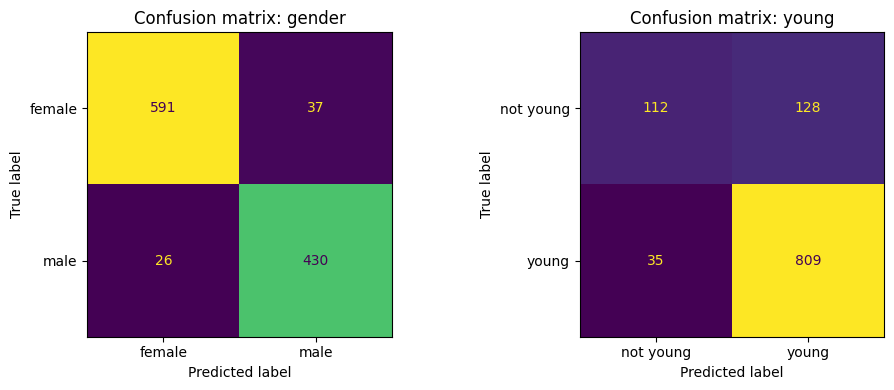

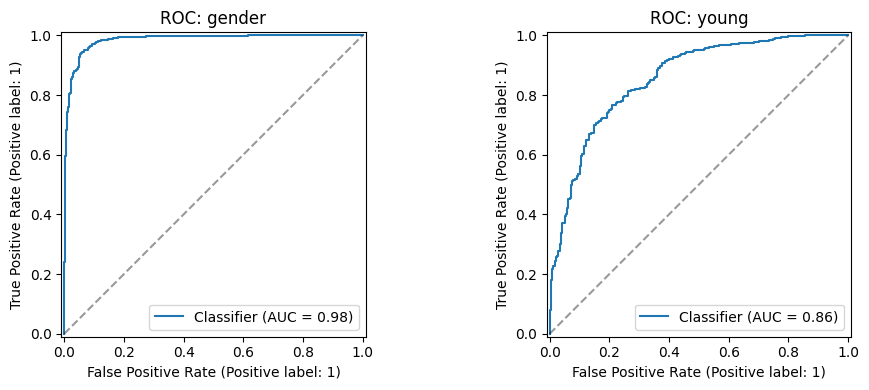

In [ ]:
pg, py = pg1, py1
tasks = (("gender", pg, ["female", "male"]), ("young", py, ["not young", "young"]))


fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for a, (task, prob, names) in zip(ax, tasks):
    ConfusionMatrixDisplay.from_predictions(test_df[task].values, (prob >= 0.5).astype(int),
                                            display_labels=names, ax=a, colorbar=False)
    a.set_title(f"Confusion matrix: {task}")
plt.tight_layout(); plt.show()


fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for a, (task, prob, _) in zip(ax, tasks):
    RocCurveDisplay.from_predictions(test_df[task].values, prob, ax=a)
    a.plot([0, 1], [0, 1], "k--", alpha=0.4)
    a.set_title(f"ROC: {task}")
plt.tight_layout(); plt.show()

## Stage 8. Error analysis and bias check

A single accuracy number hides **where** the model makes mistakes. We look at:
1. accuracy separately for groups (gender, glasses, hat, smile);
2. the most *confident* errors, by eye.

In [ ]:
ev = test_df.copy()
ev["ok_gender"] = ((pg >= 0.5).astype(int) == ev["gender"]).astype(int)
ev["ok_young"]  = ((py >= 0.5).astype(int) == ev["young"]).astype(int)

rows = []
for col in ["gender", "Eyeglasses", "Wearing_Hat", "Smiling"]:
    g = ev.groupby(col).agg(n=("file", "size"),
                            acc_gender=("ok_gender", "mean"),
                            acc_young=("ok_young", "mean")).reset_index()
    g.insert(0, "feature", col)
    rows.append(g.rename(columns={col: "value"}))
slice_df = pd.concat(rows).round(3)

print("For gender: 0 = female, 1 = male. For the others: 1 = the feature is present.")
slice_df

For gender: 0 = female, 1 = male. For the others: 1 = the feature is present.


,feature,value,n,acc_gender,acc_young
0,gender,0,628,0.941,0.906
1,gender,1,456,0.943,0.772
0,Eyeglasses,0,1008,0.946,0.856
1,Eyeglasses,1,76,0.882,0.763
0,Wearing_Hat,0,1035,0.945,0.854
1,Wearing_Hat,1,49,0.878,0.755
0,Smiling,0,576,0.925,0.851
1,Smiling,1,508,0.961,0.848


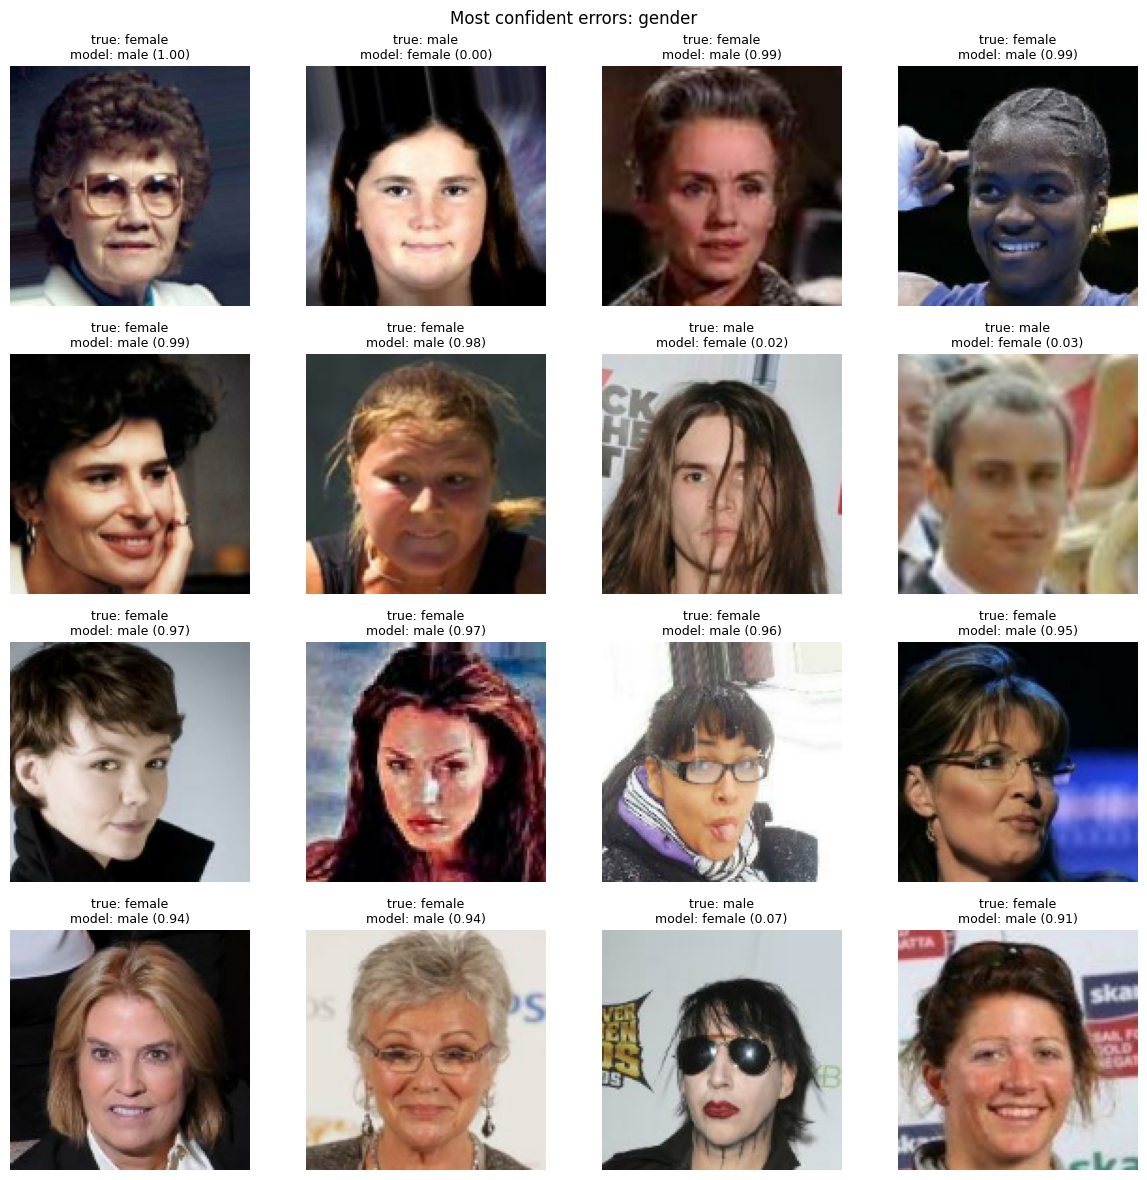

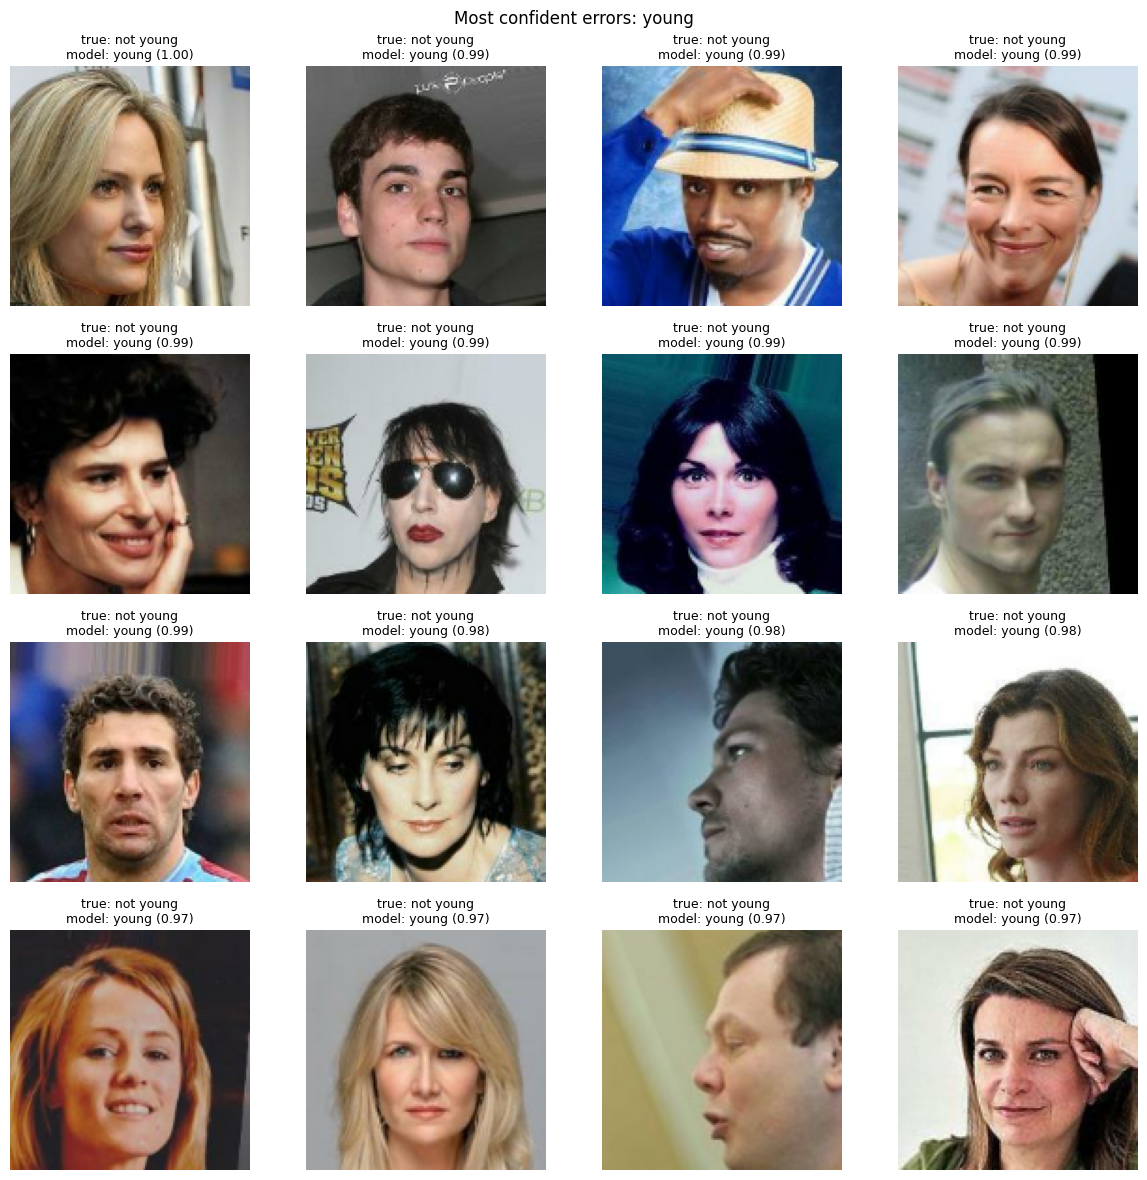

In [ ]:
def show_errors(prob, task, class_names, k=16):
    y = test_df[task].values
    pred = (prob >= 0.5).astype(int)
    wrong = np.where(pred != y)[0]
    if len(wrong) == 0:
        print("No errors"); return
    worst = wrong[np.argsort(-np.abs(prob[wrong] - y[wrong]))][:k]
    plt.figure(figsize=(12, 12))
    for i, idx in enumerate(worst):
        plt.subplot(4, 4, i + 1)
        plt.imshow(load_img(tf.constant(test_df.path[idx])).numpy().astype("uint8"))
        plt.axis("off")
        plt.title(f"true: {class_names[y[idx]]}\nmodel: {class_names[pred[idx]]} ({prob[idx]:.2f})",
                  fontsize=9)
    plt.suptitle(f"Most confident errors: {task}")
    plt.tight_layout(); plt.show()

show_errors(pg, "gender", ["female", "male"])
show_errors(py, "young", ["not young", "young"])

The model most often classifies women with short haircuts as men.

## Stage 9. Experiment: class weights for `young`

`young=1` for ~77% of the photos, so the model can "win" on accuracy by almost always answering "young". Class weights penalize errors on the rare class (`not young`) more heavily. Expect: accuracy may drop slightly, while F1 for `not young` should improve. Describe this trade-off in the report.

In [24]:
tf.keras.utils.set_random_seed(SEED)
n  = len(train_df)
n1 = int(train_df.young.sum())
n0 = n - n1
W_YOUNG = (n / (2 * n0), n / (2 * n1))
print("Weights (not young, young):", np.round(W_YOUNG, 3))

train_ds_w = make_ds(train_df, True, w_young=W_YOUNG)

base = build_model(dropout=0.3)
model_w = tf.keras.Model(
    inputs=base.input,
    outputs={"gender": base.outputs[0], "young": base.outputs[1]},
)
model_w = compile_model(model_w, lr=1e-3)

model_w.fit(
    train_ds_w, validation_data=val_ds, epochs=15,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                                restore_best_weights=True)],
)
evaluate_model(model_w, "frozen + weights")
show_results()

Weights (not young, young): [2.257 0.642]
Epoch 1/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 216s 1s/step - gender_acc: 0.8684 - gender_loss: 0.3160 - loss: 0.9017 - young_acc: 0.7151 - young_loss: 0.5862 - val_gender_acc: 0.8911 - val_gender_loss: 0.2671 - val_loss: 0.7591 - val_young_acc: 0.7694 - val_young_loss: 0.4923
Epoch 2/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 185s 1s/step - gender_acc: 0.8992 - gender_loss: 0.2545 - loss: 0.7813 - young_acc: 0.7437 - young_loss: 0.5273 - val_gender_acc: 0.9041 - val_gender_loss: 0.2275 - val_loss: 0.6741 - val_young_acc: 0.8035 - val_young_loss: 0.4469
Epoch 3/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 198s 1s/step - gender_acc: 0.8969 - gender_loss: 0.2499 - loss: 0.7562 - young_acc: 0.7575 - young_loss: 0.5054 - val_gender_acc: 0.9022 - val_gender_loss: 0.2262 - val_loss: 0.6510 - val_young_acc: 0.8054 - val_young_loss: 0.4251
Epoch 4/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - gender_acc: 0.9035 - gender_loss: 0.2339 - loss: 0.7324 - young_acc: 0.7614 - young_loss: 

,model,task,accuracy,f1,roc_auc,baseline_acc
0,frozen,gender,0.896,0.877,0.971,0.579
1,frozen,young,0.832,0.897,0.840,0.779
2,finetuned,gender,0.942,0.932,0.985,0.579
3,finetuned,young,0.850,0.908,0.856,0.779
4,frozen + weights,gender,0.902,0.886,0.970,0.579
5,frozen + weights,young,0.794,0.863,0.844,0.779
